# House Pricing

## Background

Property developers or real estate agents generally determine home selling prices based on intuition or market averages, without the support of structured mathematical analysis. This approach risks producing suboptimal prices—either too high, thus discouraging buyers, or too low, thus reducing profit margins.

To address this issue, we can use a price elasticity-based approach, which quantifies the sensitivity of demand to price changes. The optimal selling price is calculated using the formula:

$$\text{Optimal Price} = \text{Cost of Capital} \times \left( \frac{\text{Elasticity}}{1 + \text{Elasticity}} \right)$$

**Main Components:**
- **Capital Cost:** Includes land, construction, labor, and permit costs.
- **Price Elasticity:** Measures the sensitivity of demand to changes in price per unit area.

**Interpretation of Elasticity:**
- **Elastic Market (Elasticity > 1):** Even a small price increase can cause a significant decrease in demand. This is common in the lower-middle class housing segment — prices must be kept competitive.
- **Inelastic Market (Elasticity < 1):** Price increases do not significantly affect purchasing interest, for example, in premium homes in strategic locations. Companies have greater flexibility to increase margins.

## Business Objective & Tasks

**Business Objective:**
Maximize the profits of a property company by determining the optimal selling price for a house based on data.

**Tasks/Initiatives:**
1. Estimate price elasticity using log-log regression (OLS).
2. Calculate the optimal price based on elasticity and cost of capital.
3. Simulate profit projections for various area scenarios.

In [1]:
# The following code is to import libraries necessary to run this notebook

# Data manipulation
import pandas as pd
import numpy as np

# Model fitting
import statsmodels.formula.api as smf

# Visualization
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
def print_coef_std_err(results):
    """
    Function to combine estimated coefficients and standard error in one DataFrame
    :param results: <statsmodels RegressionResultsWrapper> OLS regression results
    :return df: <pandas DataFrame>
    """
    coef = results.params
    std_err = results.bse

    df = pd.DataFrame(data = np.transpose([coef, std_err]),
                      index = coef.index,
                      columns=["coef","std err"])
    return df

In [3]:
house = pd.read_csv('Housing.csv')
house.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


**Scale better unit for price**

- Changes price in terms of thousand dollars. Unit dollars are too granular.
- We can achieve this by rescaling the price variable.

In [ ]:
house['price'] = house['price']/1000
house.head()

## Data Exploration: Visualizing the Relationship Between Price and Area

Before building a model, we need to understand the relationship between the variables **Price** and **Area** through a scatterplot visualization.

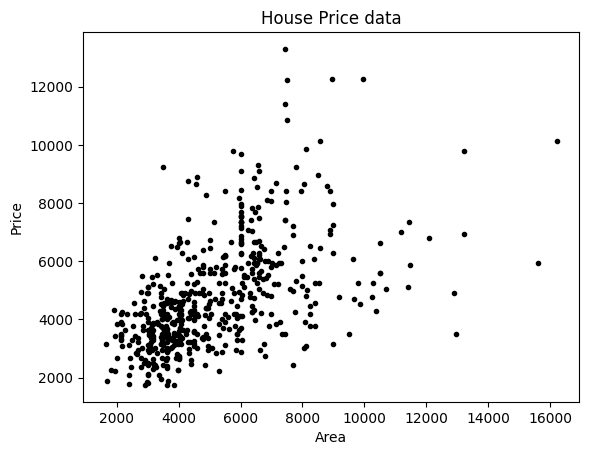

In [6]:
x = house['area']
y = house['price']

# plot the data
plt.scatter(x, y, color = 'k', marker='.')

# add a legend and labels
plt.xlabel('Area')
plt.ylabel('Price')

# add a title
plt.title('House Price data')

# show data
plt.show()


**Problem:** The scatterplot shows that the relationship between area and house prices is **not linear** — there is a clear non-linear pattern. Therefore, simple linear regression cannot be directly applied to this raw data.

## Approach: Log Transformation for Elasticity Estimation

To estimate price elasticity, we need to measure the relationship between variables in units of **percentage change** (rather than absolute units). This is achieved through a logarithmic transformation of both variables.

In a **log-log** model, the regression coefficients directly yield the elasticity values:

$$\frac{\% \Delta \text{Price}}{\% \Delta \text{Area}} = \beta_1$$

This means that if the coefficient $\beta_1 = 0.54$, then a 1% increase in area is associated with a 0.54% increase in price.

### Log Transformation

Logarithmic transformation was applied to the **price** and **area** variables to convert the data to log-scale before modeling.

In [7]:
house['logPrice'] = np.log(house['price'])
house['logArea'] = np.log(house['area'])

### Fit Linear Regression

In [8]:
# Create OLS model object
model = smf.ols("logPrice ~ logArea", house)

# Fit the model
results = model.fit()

# Extract the results (Coefficient and Standard Error) to DataFrame
results_house = print_coef_std_err(results)

In [9]:
results.rsquared

np.float64(0.33649906166120647)

The following is a visualization of log-log data along with the regression line that has been fitted by the OLS model.

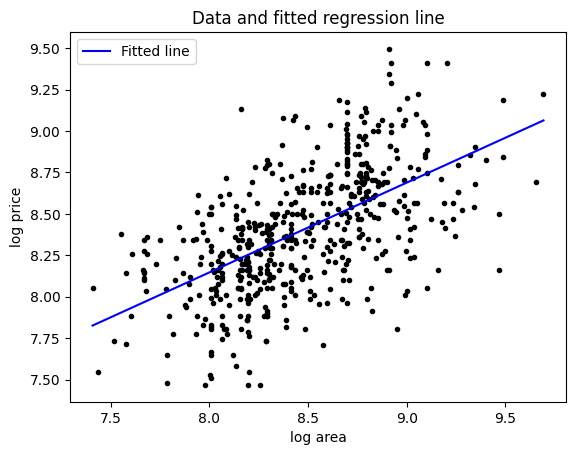

In [10]:
predictor = "logArea"
outcome = "logPrice"
data = house.copy()
results_ = results_house.copy()

# Plot the data
plt.scatter(data[predictor], data[outcome], color = "k", marker=".")

# Calculate the fitted values
a_hat = results_.loc["Intercept"]["coef"]
b_hat = results_.loc[predictor]["coef"]

x_domain = np.linspace(np.min(data[predictor]), np.max(data[predictor]), len(data))

fitted_values = a_hat + b_hat * x_domain

# Plot the fitted line
plt.plot(x_domain, fitted_values, label="Fitted line", color = "b")

# Add a legend and labels
plt.legend()
plt.ylabel("log price")
plt.xlabel("log area")

# Add a title and adjust the margins
plt.title("Data and fitted regression line")

# Show the plot
plt.show()


**Finding:** After logarithmic transformation, the relationship between `logArea` and `logPrice` appears **linear** — this confirms that the log-log model is appropriate for this data.

### Coefficient Interpretation

In [11]:
results_house

,coef,std err
Intercept,3.809987,0.276853
logArea,0.542045,0.032664


$$\text{logPrice} = 3.8 + 0.54\times\text{logArea}$$

**Coefficient Interpretation:**

- The `logArea` coefficient of **0.54** indicates that every **1%** increase in area is associated with a **0.54%** increase in price.

> **Elasticity Conclusion:**
> - Elasticity value = **0.54** (<1.0) → the market is **inelastic**
> - This means that a price increase **will not** cause a drastic decrease in demand
> - Companies have room to set prices above the cost of capital to increase profit margins

### Calculate Optimal Price from the Cost and Elasticity

From the OLS model, the coefficient `logArea` = **0.54** is obtained as the elasticity value. Combined with the capital cost of **$1 per unit area**, the optimal price is calculated as:

$$\text{Optimal Price} = \$1 \times \left( \frac{0.54}{1 + 0.54} \right) = \$0.35 \text{ per unit area}$$

This value represents the **profit-maximizing price point** based on the existing cost structure and market elasticity conditions.

<font color="blue">The Optimal Price</font>

$$
\begin{align*}
\text{optimal\_price} &= \text{cost} \times \left( \frac{\text{elasticity}}{1 + \text{elasticity}} \right) \\
&= (\$1) \times \left( \frac{0.54}{1 + 0.54} \right) \\
&= (\$1) (0.35) \\
\text{optimal\_price} &= \$0.35
\end{align*}
$$

### Optimal Price and The Expected Profit

**Step 1: Market Price Prediction for Different Area Size Scenarios**

We simulated price predictions for three different area sizes (4,000, 2,300, and 1,500 sq ft) using a pre-built log-log regression model.

In [12]:
area_list = np.array([4000, 2300, 1500])

prediction_results = pd.DataFrame(data = {"area": area_list})
prediction_results


,area
0,4000
1,2300
2,1500


In [13]:
# Calculate the log transform of each area
prediction_results['logArea'] = np.log(prediction_results['area'])

# Prediction results
prediction_results["pred_logPrice"] = results.predict(prediction_results["logArea"])
prediction_results["pred_Price"] = np.exp(prediction_results["pred_logPrice"])

prediction_results


,area,logArea,pred_logPrice,pred_Price
0,4000,8.294050,8.305735,4047.017334
1,2300,7.740664,8.005776,2998.224874
2,1500,7.313220,7.774082,2378.158577


**Step 2: Calculating Projected Profit**

Profit is calculated as the difference between the predicted market price and the total cost of capital (cost per unit area × area).

In [14]:
# Calculate the profit
cost = 1  # cost per unit area
prediction_results["profit"] = prediction_results["pred_Price"] \
                                - cost * prediction_results["area"]

prediction_results


,area,logArea,pred_logPrice,pred_Price,profit
0,4000,8.294050,8.305735,4047.017334,47.017334
1,2300,7.740664,8.005776,2998.224874,698.224874
2,1500,7.313220,7.774082,2378.158577,878.158577


**Profit Simulation Results Analysis:**

**1. Large Area — 4,000 sq ft (Thin Margin)**
The model predicts a market price of approximately $4,047 K for a 4,000 sq ft area. Despite the high absolute value, the resulting profit is only **$47 K** — very slim. This occurs because the total capital cost ($4,000) nearly equals the predicted selling price.

**2. Medium Area — 1,500 sq ft (Highest Profit)**
For a 1,500 sq ft area, the model predicts a price of approximately $2,378 K, resulting in a profit of **$878 K** — much more efficient. This reflects conditions where the price per unit area is close to the optimal $350, resulting in a relatively large profit margin.

**3. Underpriced Condition (Price Too Low)**
If the price is lowered significantly below the optimal price (e.g., $100/unit area), the margin per unit becomes too thin and unable to cover the full cost of capital, resulting in a significant decrease in profits.

## Summary & Recommendations

This analysis shows that optimal property pricing depends not only on the area, but also on the balance between the cost of capital and market elasticity.

**Key Findings:**
- The estimated price elasticity from the log-log model is 0.54, indicating an inelastic market.
- The theoretical optimal price is approximately $350 per unit area.
- Simulations show that a 1,500 sq ft property generates the highest profit ($878 K), compared to a 4,000 sq ft property, which only generates $47 K.

**Recommendations:**
Companies are advised to adjust their pricing strategies to approach the optimal price point, especially in the mid-sized property segment. This elasticity-based approach can be used as a basis for more structured and data-driven pricing decisions than heuristic methods.

**Limitations:**
This model relies on a single predictor (area), which may oversimplify the pricing dynamics. Future work could incorporate multivariable regression using additional features such as number of bedrooms, location, and property condition for a more robust estimate